# Sales & Customer Intelligence Platform — end-to-end walkthrough

**Dataset:** [Olist Brazilian E-Commerce](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)
— 99,441 real marketplace orders, Sep 2016 → Oct 2018.

This notebook walks the whole pipeline in the order it actually runs:

| Step | What happens |
|---|---|
| 1 | Audit the raw CSVs — and find the trap that breaks most analyses of this dataset |
| 2 | Load raw → staging tables |
| 3 | Build the star schema (5 dimensions, 3 facts) from SQL models |
| 4 | Build 10 analytics marts (+ 8 dashboard cubes) |
| 5 | Assert data quality — 12 checks that must pass |
| 6 | Headline KPIs |
| 7–12 | The six analyses: trend, retention, RFM, category, geography, delivery |
| 13 | Ask the warehouse a question in plain English |

Every number below is computed live from the warehouse — nothing is hard-coded.

In [1]:
import sys, warnings
from pathlib import Path

# Make the project importable when the notebook is run from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

from src.config import get_warehouse
from src.viz import mpl_style
from src.viz.palette import CATEGORICAL_LIGHT, CONTEXT_LIGHT, ORDINAL_LIGHT, STATUS

mpl_style.apply()
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

ACCENT, CONTEXT = mpl_style.ACCENT, mpl_style.CONTEXT
print(f"pandas {pd.__version__}")

pandas 2.2.3


---
## Step 1 — Audit the raw data

Before modelling anything, look at what actually arrived. The nine Olist CSVs
are clean by public-dataset standards, but there is one structural trap in
them that silently invalidates any customer analysis built on the obvious key.

In [2]:
RAW = ROOT / "data" / "raw"
files = sorted(RAW.glob("*.csv"))

audit = []
for f in files:
    df = pd.read_csv(f, encoding="utf-8-sig", nrows=None)
    audit.append({
        "file": f.name.replace("olist_", "").replace("_dataset.csv", ""),
        "rows": len(df),
        "cols": df.shape[1],
        "null_cells_%": round(100 * df.isna().sum().sum() / df.size, 2),
        "exact_dupes": int(df.duplicated().sum()),
        "size_mb": round(f.stat().st_size / 1e6, 1),
    })

pd.DataFrame(audit).sort_values("rows", ascending=False).reset_index(drop=True)

,file,rows,cols,null_cells_%,exact_dupes,size_mb
0,geolocation,1000163,5,0.00,261831,61.3
1,order_items,112650,7,0.00,0,15.4
2,order_payments,103886,5,0.00,0,5.8
3,order_reviews,100000,7,20.93,0,14.4
4,customers,99441,5,0.00,0,9.0
5,orders,99441,8,0.62,0,17.7
6,products,32951,9,0.83,0,2.4
7,sellers,3095,4,0.00,0,0.2
8,product_category_name_translation.csv,71,2,0.00,0,0.0


### The trap: `customer_id` is not a customer

Olist mints a **new `customer_id` for every order**. The column that identifies
a *person* across orders is `customer_unique_id`. Join on the wrong one and
every buyer looks like a first-time buyer — repeat rate reads as 0%, and cohort
retention is a flat line of zeros.

This is why `dim_customer` in this project is keyed on `customer_unique_id`.

In [3]:
cust = pd.read_csv(RAW / "olist_customers_dataset.csv")

n_order_keys  = cust["customer_id"].nunique()
n_people      = cust["customer_unique_id"].nunique()

print(f"customer_id        (per-order key) : {n_order_keys:,}")
print(f"customer_unique_id (per-person key): {n_people:,}")
print(f"\nCollapsing to real people removes {n_order_keys - n_people:,} phantom customers.")

repeat = cust.groupby("customer_unique_id").size()
print(f"\nIf you use customer_id   -> repeat customers: 0 (0.00%)  <- WRONG")
print(f"If you use unique_id     -> repeat customers: {(repeat > 1).sum():,} "
      f"({100 * (repeat > 1).mean():.2f}%)  <- correct")

customer_id        (per-order key) : 99,441
customer_unique_id (per-person key): 96,096

Collapsing to real people removes 3,345 phantom customers.

If you use customer_id   -> repeat customers: 0 (0.00%)  <- WRONG
If you use unique_id     -> repeat customers: 2,997 (3.12%)  <- correct


---
## Step 2–4 — Build the warehouse

The pipeline is a module, not notebook cells, so the same code runs from CI:

```bash
python -m src.etl.run_pipeline            # Postgres if reachable, else SQLite
python -m src.etl.run_pipeline --backend postgres
```

It does four things: load the CSVs into `stg_*` tables, compile and run the SQL
models in `sql/models/`, assert data quality, and export the Tableau extracts.

Each SQL model is written **once** against a small macro layer
(`{{ month_start(col) }}`, `{{ days_between(a, b) }}`, …) and compiled to either
PostgreSQL or SQLite at run time — so one set of models serves both backends
instead of two drifting copies.

In [4]:
from src.etl.sql_runner import parse_model, compile_sql

model = parse_model(ROOT / "sql" / "models" / "31_mart_kpi_monthly.sql")
snippet = [ln for ln in model.select_sql.splitlines() if "month_start" in ln][0]

print("model source :", snippet.strip()[:78])
print()
for dialect in ("postgresql", "sqlite"):
    print(f"-> {dialect:<11}:", compile_sql(snippet, dialect).strip()[:78])

model source : {{ month_start(order_date) }}                                    AS month_star

-> postgresql : CAST(DATE_TRUNC('month', order_date) AS DATE)                                 
-> sqlite     : DATE(order_date, 'start of month')                                    AS month


In [5]:
# Connect to whatever the pipeline last built.
wh = get_warehouse()
q = lambda sql: pd.read_sql(sql, wh.engine)
print(f"Connected to {wh.dialect}")

inventory = q("""
    SELECT 'fact'  AS layer, 'fact_orders'      AS table_name, COUNT(*) AS rows FROM fact_orders
    UNION ALL SELECT 'fact', 'fact_order_items', COUNT(*) FROM fact_order_items
    UNION ALL SELECT 'fact', 'fact_payments',    COUNT(*) FROM fact_payments
    UNION ALL SELECT 'dim',  'dim_customer',     COUNT(*) FROM dim_customer
    UNION ALL SELECT 'dim',  'dim_product',      COUNT(*) FROM dim_product
    UNION ALL SELECT 'dim',  'dim_seller',       COUNT(*) FROM dim_seller
    UNION ALL SELECT 'dim',  'dim_date',         COUNT(*) FROM dim_date
    UNION ALL SELECT 'dim',  'dim_geography',    COUNT(*) FROM dim_geography
    UNION ALL SELECT 'mart', 'mart_rfm',         COUNT(*) FROM mart_rfm
    UNION ALL SELECT 'mart', 'mart_kpi_monthly', COUNT(*) FROM mart_kpi_monthly
""")
inventory

Connected to sqlite


,layer,table_name,rows
0,fact,fact_orders,99441
1,fact,fact_order_items,112650
2,fact,fact_payments,103886
3,dim,dim_customer,96096
4,dim,dim_product,32951
5,dim,dim_seller,3095
6,dim,dim_date,777
7,dim,dim_geography,19010
8,mart,mart_rfm,94986
9,mart,mart_kpi_monthly,25


### Step 5 — Data quality gate

The pipeline exits non-zero if any check fails, so a broken model cannot
silently ship a dashboard. These are contracts, not smoke tests: two of them
(revenue reconciliation and cohort month-0) caught real bugs while this project
was being built.

In [6]:
from src.etl.checks import run_checks

report = run_checks(wh)
print(report.render())

check                                       value  expectation
-------------------------------------------------------------------------
orders_row_count                           99,441  == 99,441 (published Olist order count)  [PASS]
orders_unique_grain                             0  == 0 duplicate order_id  [PASS]
order_items_unique_grain                        0  == 0 duplicate line-item key  [PASS]
customers_collapse_ratio                   96,096  between 90k and 99,441 (unique people < order-level ids)  [PASS]
no_orphan_orders                                0  == 0 orders without a customer  [PASS]
revenue_reconciles_to_line_items                0  < R$1.00 difference between order and line-item revenue  [PASS]
no_negative_revenue                             0  == 0 negative price or freight  [PASS]
date_spine_is_contiguous                        0  == 0 duplicate calendar dates  [PASS]
every_order_date_in_dim_date                    0  == 0 fact rows missing a date dimension ro

---
## Step 6 — Headline KPIs

A handful of numbers belongs in stat tiles, not a chart. A one-bar bar chart
communicates less than the number written large.

### A note on currency

Every monetary value in the warehouse is Brazilian Real, because Olist is a
Brazilian marketplace. The figures below are shown in pounds, which means they
have been **converted, not relabelled** — at a fixed rate documented in
`src/viz/money.py`.

That distinction is the whole point. Swapping `R$` for `£` without applying a
rate would overstate every number by roughly 4.5x while still looking entirely
plausible. Conversion happens only at display time; the stored data is never
touched, so nothing downstream inherits a rounding decision. Set
`DISPLAY_CURRENCY=BRL` to see the source values.

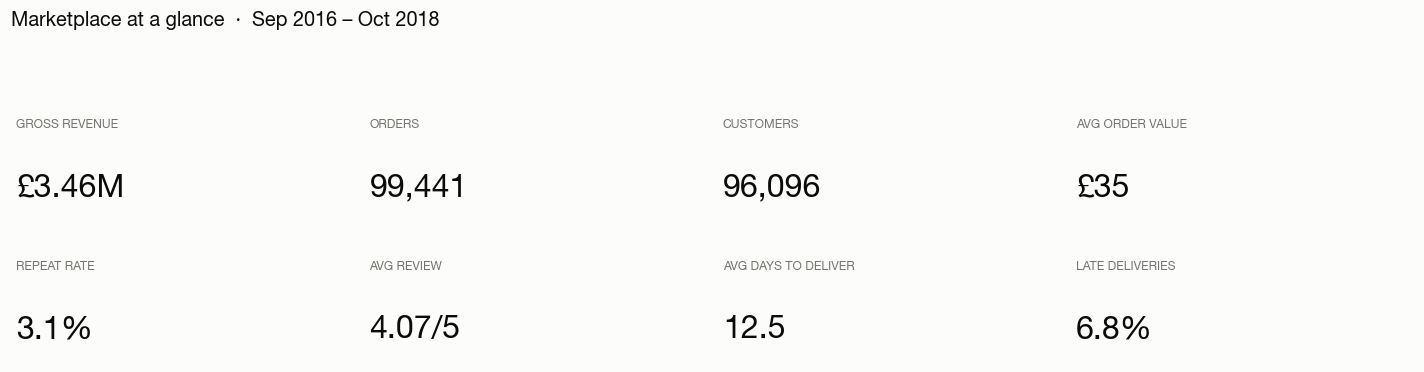

In [7]:
kpi = q("""
    SELECT
        COUNT(*)                                                       AS orders,
        SUM(CASE WHEN is_valid_sale = 1 THEN gross_revenue ELSE 0 END) AS revenue,
        COUNT(DISTINCT customer_key)                                   AS customers,
        AVG(review_score)                                              AS avg_review,
        AVG(days_to_deliver)                                           AS avg_days,
        SUM(COALESCE(is_late_delivery, 0)) * 100.0
            / SUM(CASE WHEN is_late_delivery IS NOT NULL THEN 1 ELSE 0 END) AS late_pct,
        SUM(CASE WHEN is_valid_sale = 1 THEN freight_revenue ELSE 0 END) * 100.0
            / SUM(CASE WHEN is_valid_sale = 1 THEN gross_revenue ELSE 0 END) AS freight_pct
    FROM fact_orders
""").iloc[0]

repeat_pct = q("SELECT 100.0 * SUM(is_repeat_customer) / COUNT(*) AS p FROM dim_customer").iloc[0]["p"]
aov = kpi["revenue"] / q("SELECT SUM(is_valid_sale) AS n FROM fact_orders").iloc[0]["n"]

tiles = [
    ("Gross revenue",   mpl_style.compact_brl(kpi["revenue"])),
    ("Orders",          f"{int(kpi['orders']):,}"),
    ("Customers",       f"{int(kpi['customers']):,}"),
    ("Avg order value", mpl_style.brl(aov)),
    ("Repeat rate",     f"{repeat_pct:.1f}%"),
    ("Avg review",      f"{kpi['avg_review']:.2f}/5"),
    ("Avg days to deliver", f"{kpi['avg_days']:.1f}"),
    ("Late deliveries", f"{kpi['late_pct']:.1f}%"),
]

fig, axes = plt.subplots(2, 4, figsize=(13, 3.4))
for ax, (label, value) in zip(axes.ravel(), tiles):
    ax.axis("off")
    ax.set_facecolor("none")
    ax.text(0, 0.72, label.upper(), fontsize=8, color="#75736d")
    ax.text(0, 0.18, value, fontsize=21, weight="600", color="#0b0b0b")
fig.suptitle("Marketplace at a glance  ·  Sep 2016 – Oct 2018",
             x=0.008, ha="left", fontsize=13, weight="600")
fig.tight_layout(rect=[0, 0, 1, 0.9])
plt.show()

---
## Step 7 — Revenue trend

One series is the point (monthly revenue); the 3-month average is context. That
is the **emphasis** form — one accent hue, everything else grey — rather than
two competing colours.

Note the deliberate absence of a second y-axis. Revenue and growth-% are
different scales, so growth is annotated on the line instead of given its own
axis, which would let the chart imply any correlation the author wanted.

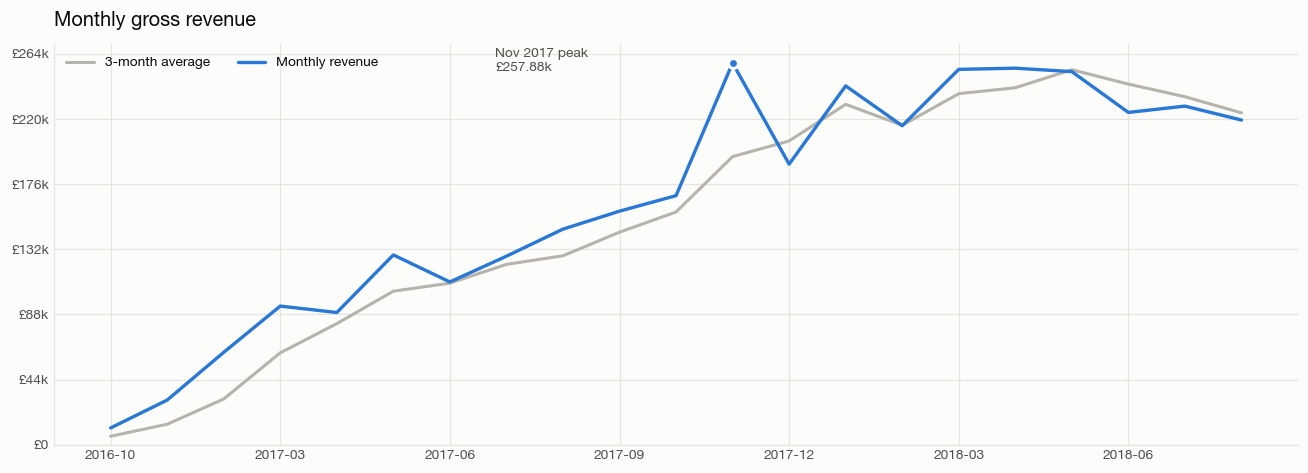

Excluded as near-empty (<50 valid orders): 2016-09, 2016-12, 2018-09, 2018-10
year_month  orders  valid_orders
   2016-09       4             2
   2016-12       1             1
   2018-09      16             1
   2018-10       4             0


In [8]:
m = q("SELECT year_month, month_start_date, revenue, orders, avg_order_value, "
      "revenue_mom_pct FROM mart_kpi_monthly ORDER BY month_start_date")
m["ma3"] = m["revenue"].rolling(3, min_periods=1).mean()

# The first and last months are near-empty; charting them raw implies a crash
# that did not happen. Flag rather than silently drop.
sparse = q("SELECT year_month FROM mart_kpi_monthly WHERE valid_orders < 50")["year_month"].tolist()
core = m[~m["year_month"].isin(sparse)]

fig, ax = plt.subplots(figsize=(12, 4.4))
x = range(len(core))
ax.plot(x, core["ma3"], color=CONTEXT, lw=2, label="3-month average")
ax.plot(x, core["revenue"], color=ACCENT, lw=2.2, label="Monthly revenue")

peak = core["revenue"].idxmax()
peak_x = core.index.get_loc(peak)
ax.scatter([peak_x], [core.loc[peak, "revenue"]], s=42, color=ACCENT, zorder=5,
           edgecolor="#fcfcfb", linewidth=2)
ax.annotate(f"Nov 2017 peak\n{mpl_style.compact_brl(core.loc[peak, 'revenue'])}",
            xy=(peak_x, core.loc[peak, "revenue"]), xytext=(peak_x - 4.2, core.loc[peak, "revenue"] * 0.98),
            fontsize=9, color="#52514e")

ax.set_xticks(list(x)[::3])
ax.set_xticklabels(core["year_month"].iloc[::3], rotation=0)
ax.yaxis.set_major_formatter(FuncFormatter(lambda v, _: mpl_style.compact_brl(v)))
ax.set_title("Monthly gross revenue")
ax.set_ylim(0)
ax.legend(loc="upper left", ncol=2)
plt.tight_layout(); plt.show()

print(f"Excluded as near-empty (<50 valid orders): {', '.join(sparse)}")
print(q("""SELECT year_month, orders, valid_orders,
                 SUM(CASE WHEN 1=1 THEN 0 END) AS x FROM mart_kpi_monthly
          WHERE valid_orders < 50 GROUP BY year_month, orders, valid_orders
          ORDER BY year_month""").drop(columns="x").to_string(index=False))

The tail is not a demand collapse. September and October 2018 hold **20 orders
between them, 19 of which were cancelled** — the dataset simply stops. Charting
those months unflagged is the most common way this dataset gets misread.

---
## Step 8 — Cohort retention

Magnitude on a grid → **heatmap with a single-hue sequential ramp**. More is
darker; there is no rainbow to decode.

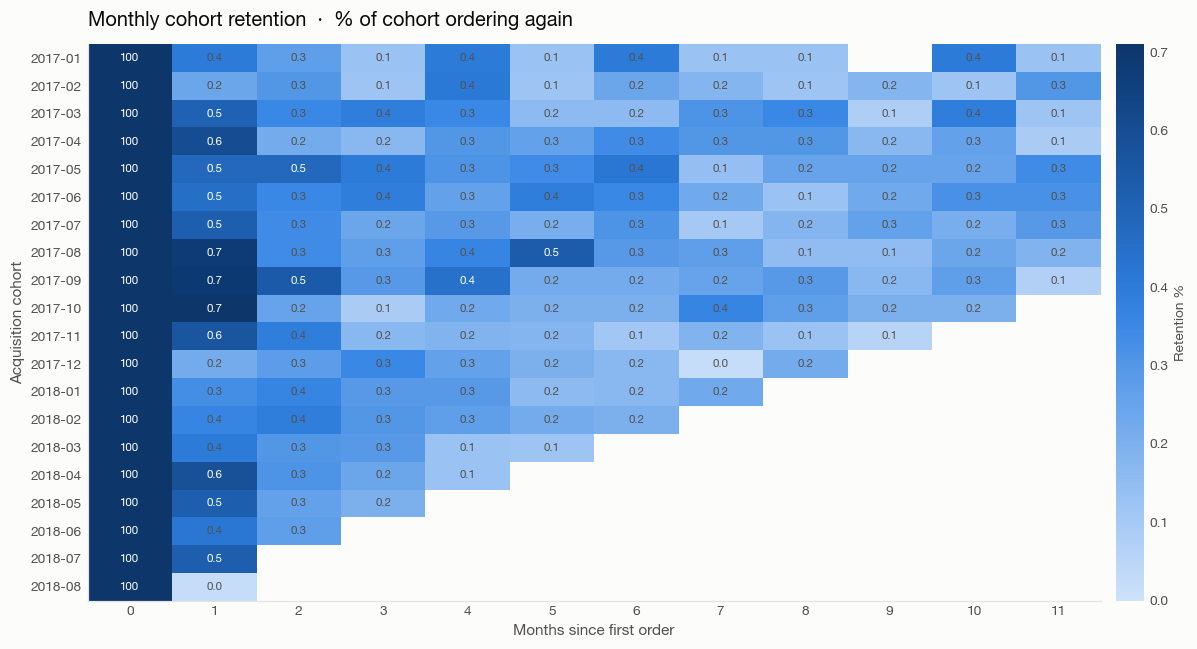

Weighted month-1 retention across all cohorts: 0.45%


In [9]:
coh = q("""
    SELECT cohort_label, months_since_first_order, retention_pct, cohort_customers
    FROM mart_cohort_retention
    WHERE months_since_first_order <= 11
""")
big = coh[coh["cohort_customers"] >= 500]          # ignore the 4-customer 2016 cohorts
grid = big.pivot(index="cohort_label", columns="months_since_first_order",
                 values="retention_pct").sort_index()

fig, ax = plt.subplots(figsize=(11, 6))
# Month 0 is 100% by construction; including it in the colour scale would flatten
# every other cell to white. Scale on months 1+ instead.
vmax = np.nanmax(grid.iloc[:, 1:].values) if grid.shape[1] > 1 else 1
im = ax.imshow(grid.values, cmap=mpl_style.BLUES, aspect="auto", vmin=0, vmax=max(vmax, 0.1))

ax.set_xticks(range(grid.shape[1])); ax.set_xticklabels(grid.columns)
ax.set_yticks(range(grid.shape[0])); ax.set_yticklabels(grid.index)
ax.set_xlabel("Months since first order"); ax.set_ylabel("Acquisition cohort")
ax.set_title("Monthly cohort retention  ·  % of cohort ordering again")
ax.grid(False)

for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        if np.isnan(v):
            continue
        # Direct labels: identity is never colour-alone.
        ax.text(j, i, "100" if j == 0 else f"{v:.1f}", ha="center", va="center",
                fontsize=7.5, color="#ffffff" if (j == 0 or v > vmax * 0.6) else "#52514e")

cbar = fig.colorbar(im, ax=ax, pad=0.015, fraction=0.03)
cbar.set_label("Retention %", color="#52514e", fontsize=9)
cbar.outline.set_visible(False)
plt.tight_layout(); plt.show()

w = q("""SELECT ROUND(100.0*SUM(active_customers)/SUM(cohort_customers), 2) AS pct
         FROM mart_cohort_retention WHERE months_since_first_order = 1""").iloc[0]["pct"]
print(f"Weighted month-1 retention across all cohorts: {w}%")

This is the platform's defining weakness. Weighted month-1 retention is **0.45%**
— effectively nobody comes back. Note the chart deliberately excludes month 0
from the colour scale: it is 100% by construction, and including it would wash
every real value to near-white.

---
## Step 9 — RFM segmentation

Standard RFM with one deliberate deviation: **Frequency uses fixed buckets, not
quintiles.** With 97% of customers buying exactly once, an `NTILE(5)` over
frequency would slice an all-1s column into five bands and invent loyalty tiers
that do not exist.

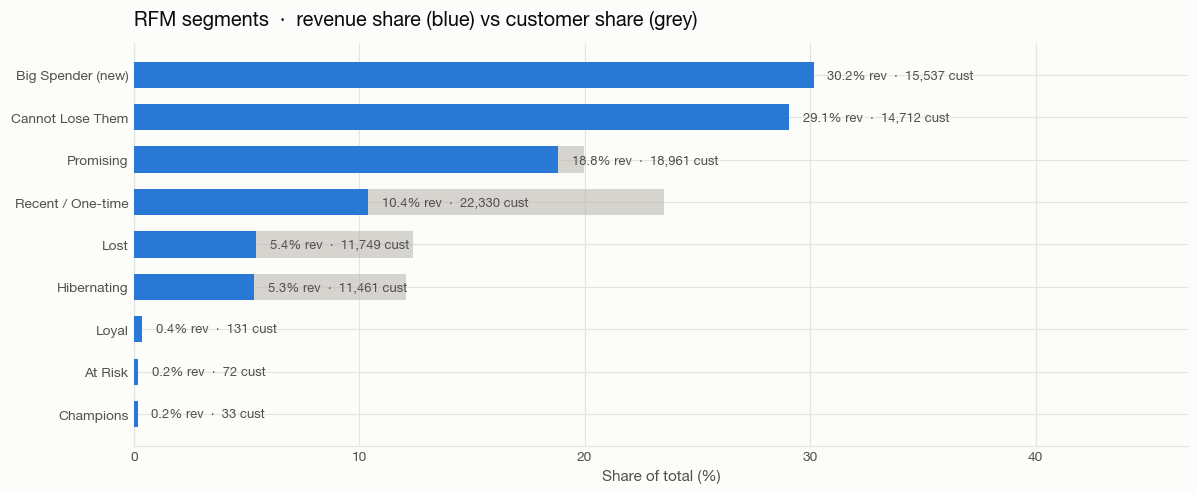

,rfm_segment,customers,revenue,avg_value,rev_share
0,Big Spender (new),15537,4746798.4,305.5,30.2
1,Cannot Lose Them,14712,4576158.1,311.0,29.1
2,Promising,18961,2962372.1,156.2,18.8
3,Recent / One-time,22330,1637163.7,73.3,10.4
4,Lost,11749,854324.7,72.7,5.4
5,Hibernating,11461,840391.6,73.3,5.3
6,Loyal,131,59650.7,455.3,0.4
7,At Risk,72,30429.2,422.6,0.2
8,Champions,33,28238.5,855.7,0.2


In [10]:
seg = q("""
    SELECT rfm_segment, COUNT(*) AS customers, SUM(monetary_value) AS revenue,
           AVG(monetary_value) AS avg_value, AVG(recency_days) AS avg_recency
    FROM mart_rfm GROUP BY rfm_segment ORDER BY revenue DESC
""")
seg["rev_share"] = 100 * seg["revenue"] / seg["revenue"].sum()
seg["cust_share"] = 100 * seg["customers"] / seg["customers"].sum()

fig, ax = plt.subplots(figsize=(11, 4.6))
y = np.arange(len(seg))[::-1]
ax.barh(y, seg["rev_share"], height=0.62, color=ACCENT, zorder=3)
ax.barh(y, seg["cust_share"], height=0.62, color=CONTEXT, zorder=2, alpha=0.55)

for yi, (_, r) in zip(y, seg.iterrows()):
    ax.text(r["rev_share"] + 0.6, yi, f"{r['rev_share']:.1f}% rev  ·  {int(r['customers']):,} cust",
            va="center", fontsize=8.5, color="#52514e")

ax.set_yticks(y); ax.set_yticklabels(seg["rfm_segment"])
ax.set_xlabel("Share of total (%)"); ax.set_xlim(0, max(seg["rev_share"]) * 1.55)
ax.set_title("RFM segments  ·  revenue share (blue) vs customer share (grey)")
plt.tight_layout(); plt.show()

seg[["rfm_segment", "customers", "revenue", "avg_value", "rev_share"]].round(1)

The loyalty tiers are almost empty — 33 Champions out of 95k customers — and
that *is* the finding. Growth here is an acquisition-efficiency problem, not a
loyalty-programme problem, and any retention initiative starts from a near-zero
base rather than optimising an existing one.

---
## Step 10 — Category concentration (Pareto)

A Pareto chart is normally drawn with a second y-axis for the cumulative line —
which is exactly the chart mistake that lets two unrelated scales imply a
relationship. Here **both series are percentages on one axis**, so the reader
can compare them directly and the chart cannot lie by rescaling.

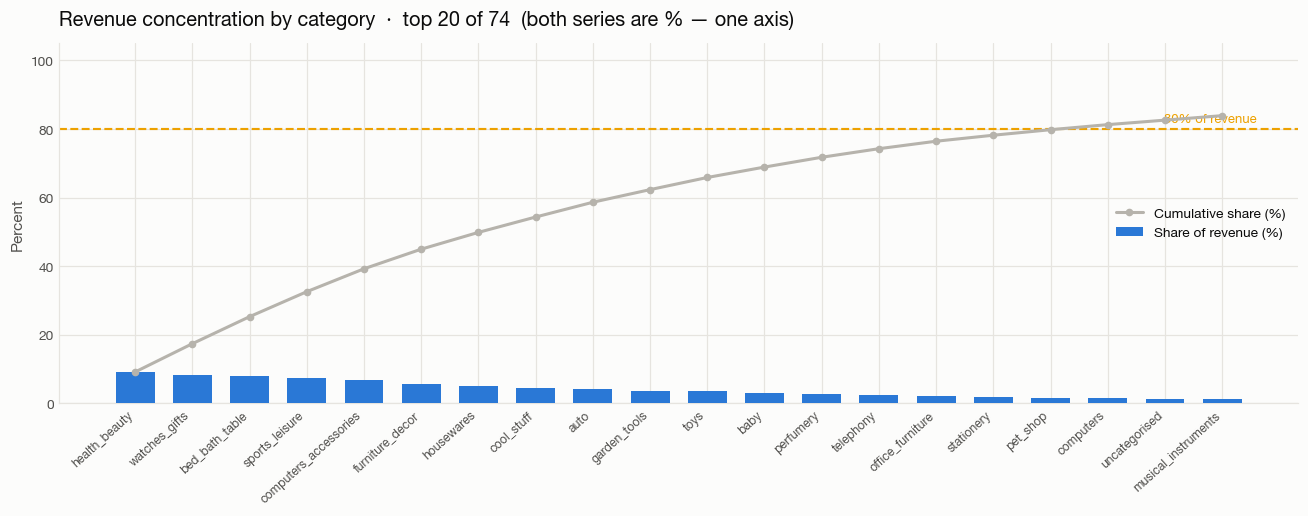

17 of 74 categories are needed to reach 80% of revenue.


In [11]:
cat = q("""SELECT category, gross_revenue, pct_of_total_revenue, cumulative_revenue_pct,
                  freight_pct_of_revenue, avg_review_score
           FROM mart_category_performance ORDER BY revenue_rank LIMIT 20""")

n80 = q("SELECT COUNT(*) AS n FROM mart_category_performance "
        "WHERE cumulative_revenue_pct <= 80").iloc[0]["n"]
total = q("SELECT COUNT(*) AS n FROM mart_category_performance").iloc[0]["n"]

fig, ax = plt.subplots(figsize=(12, 4.8))
x = np.arange(len(cat))
ax.bar(x, cat["pct_of_total_revenue"], color=ACCENT, width=0.68, zorder=3,
       label="Share of revenue (%)")
ax.plot(x, cat["cumulative_revenue_pct"], color=CONTEXT, lw=2, marker="o", ms=4,
        zorder=4, label="Cumulative share (%)")
ax.axhline(80, color=STATUS["warning"], lw=1.4, ls="--", zorder=2)
ax.text(len(cat) - 0.4, 82, "80% of revenue", ha="right", fontsize=8.5,
        color=STATUS["warning"])

ax.set_xticks(x); ax.set_xticklabels(cat["category"], rotation=42, ha="right", fontsize=8)
ax.set_ylabel("Percent"); ax.set_ylim(0, 105)
ax.set_title("Revenue concentration by category  ·  top 20 of "
             f"{int(total)}  (both series are % — one axis)")
ax.legend(loc="center right")
plt.tight_layout(); plt.show()

print(f"{int(n80)} of {int(total)} categories are needed to reach 80% of revenue.")

---
## Step 11 — Geography

Revenue is magnitude, so the map uses the same single-hue sequential ramp. The
bubble position is the median customer coordinate per state, computed in
`dim_geography` — no shapefile needed.

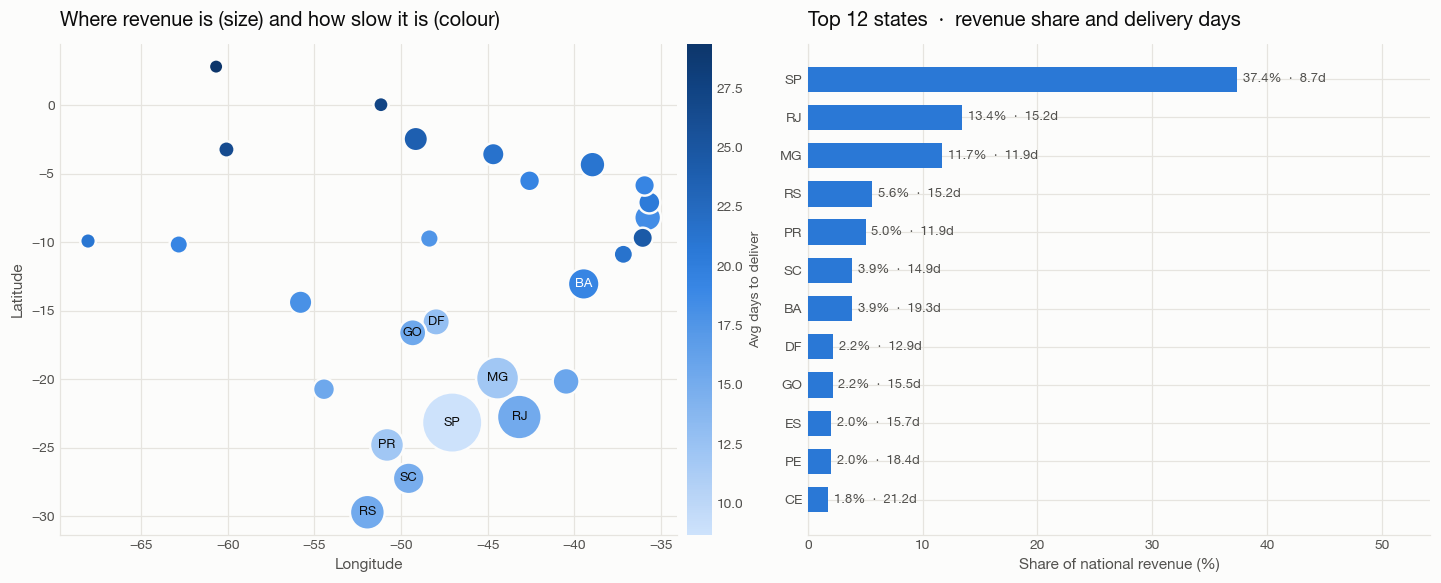

,state_code,region,pct_of_national_revenue,avg_order_value,avg_days_to_deliver,avg_review_score
0,SP,Southeast,37.37,142.97,8.70,4.16
1,RJ,Southeast,13.44,166.60,15.24,3.86
2,MG,Southeast,11.71,160.33,11.95,4.12
3,RS,South,5.58,162.00,15.25,4.12
4,PR,South,5.04,159.27,11.94,4.17
5,SC,South,3.86,168.76,14.90,4.06
6,BA,Northeast,3.86,181.52,19.28,3.83
7,DF,Central-West,2.23,165.53,12.89,4.06


In [12]:
geo = q("""SELECT state_code, region, revenue, pct_of_national_revenue, avg_order_value,
                  avg_days_to_deliver, avg_review_score, latitude, longitude, customers
           FROM mart_geo_performance WHERE latitude IS NOT NULL ORDER BY revenue DESC""")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.2, 5.4),
                               gridspec_kw={"width_ratios": [1.05, 1]})

sizes = 60 + 1500 * (geo["revenue"] / geo["revenue"].max()) ** 0.62
sc = ax1.scatter(geo["longitude"], geo["latitude"], s=sizes, c=geo["avg_days_to_deliver"],
                 cmap=mpl_style.BLUES, edgecolor="#fcfcfb", linewidth=1.6, zorder=3)
# Label ink must contrast with the bubble it sits on: the fastest states get the
# lightest fill, so white-on-white would make exactly the biggest bubble unreadable.
_lo, _hi = geo["avg_days_to_deliver"].min(), geo["avg_days_to_deliver"].max()
for _, r in geo.head(9).iterrows():
    shade = (r["avg_days_to_deliver"] - _lo) / max(_hi - _lo, 1e-9)
    ax1.annotate(r["state_code"], (r["longitude"], r["latitude"]), fontsize=8.5,
                 ha="center", va="center", weight="600", zorder=4,
                 color="#ffffff" if shade > 0.45 else "#0b0b0b")
ax1.set_title("Where revenue is (size) and how slow it is (colour)")
ax1.set_xlabel("Longitude"); ax1.set_ylabel("Latitude")
cb = fig.colorbar(sc, ax=ax1, pad=0.015, fraction=0.04)
cb.set_label("Avg days to deliver", fontsize=9, color="#52514e"); cb.outline.set_visible(False)

top = geo.head(12).iloc[::-1]
yy = np.arange(len(top))
ax2.barh(yy, top["pct_of_national_revenue"], color=ACCENT, height=0.66, zorder=3)
for yi, (_, r) in zip(yy, top.iterrows()):
    ax2.text(r["pct_of_national_revenue"] + 0.5, yi,
             f"{r['pct_of_national_revenue']:.1f}%  ·  {r['avg_days_to_deliver']:.1f}d",
             va="center", fontsize=8.5, color="#52514e")
ax2.set_yticks(yy); ax2.set_yticklabels(top["state_code"])
ax2.set_xlim(0, top["pct_of_national_revenue"].max() * 1.45)
ax2.set_xlabel("Share of national revenue (%)")
ax2.set_title("Top 12 states  ·  revenue share and delivery days")
plt.tight_layout(); plt.show()

geo.head(8)[["state_code", "region", "pct_of_national_revenue",
             "avg_order_value", "avg_days_to_deliver", "avg_review_score"]].round(2)

---
## Step 12 — Delivery speed vs satisfaction

**This is the headline operational finding of the project.**

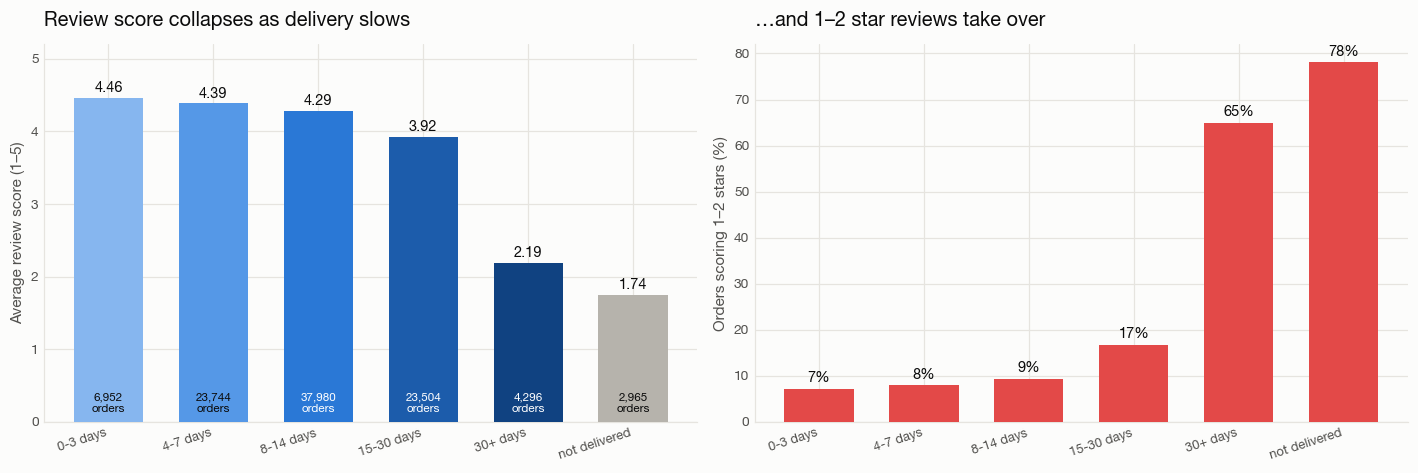

,delivery_speed_bucket,orders,avg_review,detractor_pct
0,0-3 days,6952,4.46,7.19
1,4-7 days,23744,4.39,7.98
2,8-14 days,37980,4.29,9.38
3,15-30 days,23504,3.92,16.80
4,30+ days,4296,2.19,64.99
5,not delivered,2965,1.74,78.08


In [13]:
dl = q("""
    SELECT delivery_speed_bucket, bucket_order,
           SUM(orders) AS orders,
           SUM(orders * avg_review_score) / SUM(orders) AS avg_review,
           SUM(detractor_orders) AS detractors,
           SUM(promoter_orders)  AS promoters
    FROM mart_delivery_performance
    WHERE avg_review_score IS NOT NULL
    GROUP BY delivery_speed_bucket, bucket_order ORDER BY bucket_order
""")
dl["detractor_pct"] = 100 * dl["detractors"] / dl["orders"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.4))

# Ordinal ramp: ranked stages of one hue, widely spaced so neighbours differ.
ramp = list(ORDINAL_LIGHT) + [CONTEXT]
ax1.bar(range(len(dl)), dl["avg_review"], color=ramp[:len(dl)], width=0.66, zorder=3)
for i, r in dl.iterrows():
    ax1.text(i, r["avg_review"] + 0.08, f"{r['avg_review']:.2f}", ha="center",
             fontsize=9.5, weight="600", color="#0b0b0b")
    ax1.text(i, 0.14, f"{int(r['orders']):,}\norders", ha="center", fontsize=7.6,
             color="#ffffff" if i >= 2 and i < len(dl) - 1 else "#0b0b0b")
ax1.set_xticks(range(len(dl))); ax1.set_xticklabels(dl["delivery_speed_bucket"],
                                                    rotation=18, ha="right", fontsize=8.5)
ax1.set_ylim(0, 5.2); ax1.set_ylabel("Average review score (1–5)")
ax1.set_title("Review score collapses as delivery slows")

ax2.bar(range(len(dl)), dl["detractor_pct"], color=STATUS["critical"], width=0.66, zorder=3)
for i, r in dl.iterrows():
    ax2.text(i, r["detractor_pct"] + 1.4, f"{r['detractor_pct']:.0f}%", ha="center",
             fontsize=9.5, weight="600", color="#0b0b0b")
ax2.set_xticks(range(len(dl))); ax2.set_xticklabels(dl["delivery_speed_bucket"],
                                                    rotation=18, ha="right", fontsize=8.5)
ax2.set_ylabel("Orders scoring 1–2 stars (%)")
ax2.set_title("…and 1–2 star reviews take over")
plt.tight_layout(); plt.show()

dl[["delivery_speed_bucket", "orders", "avg_review", "detractor_pct"]].round(2)

Delivery time is the strongest single lever on satisfaction in this dataset:
**4.46/5 at ≤3 days → 2.19/5 past 30 days**, monotonic across every bucket, with
the 1–2 star rate rising from 7% to 65% (78% where the order never arrived).

That reframes "our ratings are falling" from a customer-experience complaint
into a logistics target with an owner and a number attached.

---
## Step 13 — Fulfilment funnel

Built on **milestone timestamps**, not the terminal `order_status` string.
Status says where an order ended up; the timestamps say which stages it passed
through — only the latter gives real stage-to-stage conversion.

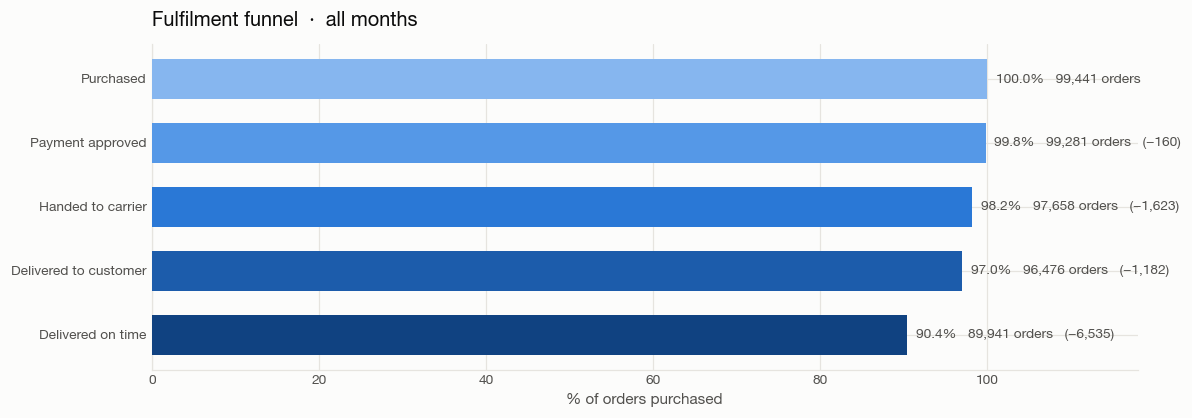

In [14]:
fun = q("""SELECT stage, stage_order, SUM(orders) AS orders
           FROM mart_order_funnel GROUP BY stage, stage_order ORDER BY stage_order""")
top = fun["orders"].iloc[0]
fun["pct"] = 100 * fun["orders"] / top
fun["drop"] = fun["orders"].shift(1) - fun["orders"]

fig, ax = plt.subplots(figsize=(11, 3.9))
y = np.arange(len(fun))[::-1]
ax.barh(y, fun["pct"], color=ORDINAL_LIGHT, height=0.62, zorder=3)
for yi, (_, r) in zip(y, fun.iterrows()):
    label = f"{r['pct']:.1f}%   {int(r['orders']):,} orders"
    if not np.isnan(r["drop"]) and r["drop"] > 0:
        label += f"   (−{int(r['drop']):,})"
    ax.text(r["pct"] + 1, yi, label, va="center", fontsize=9, color="#52514e")

ax.set_yticks(y); ax.set_yticklabels(fun["stage"])
ax.set_xlim(0, 118); ax.set_xlabel("% of orders purchased")
ax.set_title("Fulfilment funnel  ·  all months")
plt.tight_layout(); plt.show()

---
## Step 14 — Ask the warehouse in plain English

The agent translates a question into SQL against the curated schema, runs it
through a read-only guard, executes it and explains the result.

The guard is the security boundary — not the prompt. Below it is exercised
against the attacks it exists to stop.

In [15]:
from src.llm.sql_guard import guard, UnsafeSQLError
from src.llm.schema_context import get_briefing

allowed = set(get_briefing(wh).tables)

attacks = [
    ("SELECT COUNT(*) FROM fact_orders",                    "legitimate"),
    ("SELECT * FROM fact_orders; DROP TABLE fact_orders",   "statement chaining"),
    ("DROP TABLE fact_orders",                              "direct DDL"),
    ("UPDATE fact_orders SET gross_revenue = 0",            "data modification"),
    ("SELECT * FROM stg_orders",                            "reaching past the curated layer"),
    ("SELECT * FROM pg_tables",                             "catalogue probing"),
    ("SELECT * FROM fact_orders -- ; DROP TABLE x",         "comment-hidden injection"),
    ("SELECT * FROM fact_orders WHERE order_status='created'", "keyword inside a literal"),
]

rows = []
for sql, kind in attacks:
    try:
        g = guard(sql, allowed, 1000)
        rows.append({"attempt": kind, "verdict": "ALLOWED",
                     "detail": f"LIMIT injected: {g.limit_injected}"})
    except UnsafeSQLError as e:
        rows.append({"attempt": kind, "verdict": "BLOCKED", "detail": str(e)[:58]})

pd.DataFrame(rows)

,attempt,verdict,detail
0,legitimate,ALLOWED,LIMIT injected: True
1,statement chaining,BLOCKED,Only a single statement is allowed (found ';').
2,direct DDL,BLOCKED,Query must begin with SELECT or WITH.
3,data modification,BLOCKED,Query must begin with SELECT or WITH.
4,reaching past the curated layer,BLOCKED,Query references table(s) outside the curated ...
5,catalogue probing,BLOCKED,Query references table(s) outside the curated ...
6,comment-hidden injection,ALLOWED,LIMIT injected: True
7,keyword inside a literal,ALLOWED,LIMIT injected: True


In [16]:
from src.llm.agent import DataAgent
from src.llm.providers import provider_status

# What this machine could use, if anything:
for p in provider_status():
    print(f"  {'available' if p['available'] else 'not available':<15} {p['label']:<22} {p['detail']}")

# ...but this notebook deliberately pins the built-in query builder rather than
# taking whichever model happens to be installed. A generated notebook has to
# produce the same output for the next reader as it did here, and a model that
# may or may not be running -- and that never answers identically twice -- would
# make these cells unreproducible. The app itself uses whatever is available.
agent = DataAgent(wh, prefer="none")
run = agent.ask("Average review score by delivery speed")

print(f"backend: {run.source}   ({run.seconds:.1f}s)\nQ: {run.question}\n")
for s in run.steps:
    flag = "ok" if s.ok else "failed"
    print(f"--- {s.purpose} [{flag}] ({s.rows} rows, {s.seconds:.2f}s) ---")
    print(s.sql.strip(), "\n")
print("ANSWER:\n" + run.answer)

  available       Ollama (local)         qwen2.5-coder:7b
  not available   Claude (Anthropic API) no ANTHROPIC_API_KEY
backend: query_builder   (0.0s)
Q: Average review score by delivery speed

--- Average review score by delivery speed [ok] (6 rows, 0.03s) ---
SELECT CASE
            WHEN f.days_to_deliver IS NULL THEN 'not delivered'
            WHEN f.days_to_deliver <=  3   THEN '0-3 days'
            WHEN f.days_to_deliver <=  7   THEN '4-7 days'
            WHEN f.days_to_deliver <= 14   THEN '8-14 days'
            WHEN f.days_to_deliver <= 30   THEN '15-30 days'
            ELSE '30+ days' END AS delivery_band,
       ROUND(AVG(f.review_score), 2) AS review,
       SUM(f.is_valid_sale) AS orders
FROM fact_orders f
WHERE f.review_score IS NOT NULL
GROUP BY CASE
            WHEN f.days_to_deliver IS NULL THEN 'not delivered'
            WHEN f.days_to_deliver <=  3   THEN '0-3 days'
            WHEN f.days_to_deliver <=  7   THEN '4-7 days'
            WHEN f.days_to_deliver <= 

---
## Findings

1. **Delivery speed is the dominant satisfaction lever.** 4.46/5 at ≤3 days vs
   2.19/5 past 30 days, monotonic across every bucket. Compressing the 15–30 day
   tail is worth more than any product or merchandising change visible here.
2. **Retention is effectively zero.** 3.1% of customers ever reorder; weighted
   month-1 retention is 0.45%. This is an acquisition-efficiency business,
   whether or not it intends to be.
3. **Revenue is geographically concentrated but service quality is not.**
   São Paulo is 37.4% of revenue at 8.7 days to deliver; Roraima averages 29.3
   days. Interestingly northern review scores do *not* collapse proportionally —
   expectations appear to be locally calibrated.
4. **The funnel is healthy until the last mile.** 99.8% payment approval and
   97.0% delivery, but only 90.5% on time — roughly two thirds of all funnel loss
   is late arrival, i.e. an estimate-accuracy problem.
5. **Revenue is not concentrated in hero categories.** 18 of 74 categories are
   needed to reach 80% of revenue.
6. **Freight is 14.2% of gross revenue**, and rises with distance — the margin
   story and the logistics story are the same story.

### Reproduce

```bash
python scripts/download_data.py
docker compose up -d                  # optional; SQLite fallback otherwise
python -m src.etl.run_pipeline
streamlit run src/app/streamlit_app.py
```